In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.autograd as autograd
device = 'cuda:2'
import torch
import numpy as np
# Set random seeds for reproducibility
#torch.manual_seed(1)
#np.random.seed(1)

class Problems():
    def dlX_disp(self):
        domain_xcoord = np.random.uniform(-self.nelx/(2*(self.nelm)),self.nelx/(2*(self.nelm)),(self.batch_size - self.dlX_fixed.shape[0] - self.dlX_force.shape[0],1))
        domain_ycoord = np.random.uniform(-self.nely/(2*(self.nelm)),self.nely/(2*(self.nelm)),(self.batch_size - self.dlX_fixed.shape[0] - self.dlX_force.shape[0],1))
        domain_coord = np.concatenate((domain_ycoord,domain_xcoord),axis = 1)
        coord = np.concatenate((self.dlX_fixed.cpu().detach().numpy(), self.dlX_force.cpu().detach().numpy()),axis = 0)
        coord = np.concatenate((coord, domain_coord),axis = 0)
        coord = torch.tensor(coord,dtype=torch.float32,requires_grad=True).to(device)
        return coord

class Cantilever_Beam_2D(Problems):
    def __init__(self, nelx, nely, xid, yid, vf):
        # Initialize geometry parameters
        self.xid = xid
        self.yid = yid
        self.nelx = nelx
        self.nely = nely

        self.nele = self.nelx*self.nely
        self.nelm = max(self.nelx,self.nely)
        self.volfrac = vf
        self.E0 = 1
        self.nu = 0.3
        
        self.batch_size = 25000

        self.alpha_init = 1
        self.alpha_max = 100
        self.alpha_delta = 0.5
        self.penal = 3.0
        
        c_y, c_x=np.meshgrid(np.linspace(-(self.nely)/(2*self.nelm),(self.nely)/(2*self.nelm),self.nely),
                                                np.linspace(-(self.nelx)/(2*self.nelm),(self.nelx)/(2*self.nelm),self.nelx)
                                                ,indexing='ij')
        self.dlX = np.stack((c_y.reshape([-1]),c_x.reshape([-1])),axis = 1).reshape([-1,2])
        c_y, c_x=np.meshgrid(np.linspace(-(self.nely)/(2*self.nelm),(self.nely)/(2*self.nelm),2*self.nely),
                                                np.linspace(-(self.nelx)/(2*self.nelm),(self.nelx)/(2*self.nelm),2*self.nelx)
                                                ,indexing='ij')
        self.dlXSS = np.stack((c_y.reshape([-1]),c_x.reshape([-1])),axis = 1).reshape([-1,2])
        self.V = (np.max(self.dlX[:,0])-np.min(self.dlX[:,0]))*(np.max(self.dlX[:,1])-np.min(self.dlX[:,1]))

        #Problem boundary condition
        fixed_voxel = np.zeros((self.nely,self.nelx))
        fixed_voxel[:,0] = 1.0
        fixed_voxel = fixed_voxel.reshape([self.nele,1])
        dlX_fixed = self.dlX[np.where(fixed_voxel == 1.0)[0],:]

        F = 0.1
        self.F_vector = torch.tensor([[F], [0.0]], dtype=torch.float32).to(device)
        self.force_voxel = np.zeros((self.nely,self.nelx)) 
        self.force_voxel[yid,xid] = 1
        force_voxel = self.force_voxel.reshape([self.nele,1])
        dlX_force = self.dlX[np.where(force_voxel == 1)[0],:]

        self.dlX = torch.tensor(self.dlX, dtype=torch.float32,requires_grad=True).to(device)
        self.dlXSS = torch.tensor(self.dlXSS, dtype=torch.float32,requires_grad=True).to(device)
        self.dlX_fixed = torch.tensor(dlX_fixed, dtype=torch.float32,requires_grad=True).to(device)
        self.dlX_force = torch.tensor(dlX_force, dtype=torch.float32,requires_grad=True).to(device)

    def analytical_fixed_BC(self,u,coord):
        u = u*2*(1/(1+torch.exp(-20*(coord[:,1:2]+0.5))) - 0.5)
        return u

In [2]:
import torch.nn.functional as F

class TO_Net(nn.Module):
    def __init__(self):
        super(TO_Net, self).__init__()
        low_band = 0.0
        high_band = 35
        c_y, c_x=np.meshgrid(np.linspace([-high_band,low_band],[-low_band,high_band],10).reshape([-1]),
                                                    np.linspace([-high_band,low_band],[-low_band,high_band],10).reshape([-1])
                                                    ,indexing='ij')
        self.kernel1 = torch.tensor(np.stack((c_y.reshape([-1]),c_x.reshape([-1])),axis = 0),dtype=torch.float32).to(device)
        self.kernel1 = torch.nn.Parameter(self.kernel1.requires_grad_())
        self.weights1 = torch.zeros([self.kernel1.shape[1],1],dtype=torch.float32).to(device)
        self.weights1 = torch.nn.Parameter(self.weights1.requires_grad_())
            
    def forward(self, x):
        y = torch.sin(torch.matmul(x,1.0* self.kernel1 ) + torch.ones([1,self.kernel1.shape[1]]).to(device))
        y = torch.sigmoid(torch.matmul(y, self.weights1))
        return y
    
class Disp_Net(nn.Module):
    def __init__(self):
        super(Disp_Net, self).__init__()
        low_band = 0.0
        high_band = 35
        c_y, c_x=np.meshgrid(np.linspace([-high_band,low_band],[-low_band,high_band],15).reshape([-1]),
                                                    np.linspace([-high_band,low_band],[-low_band,high_band],10).reshape([-1]),
                                                    indexing='ij')
        self.kernel1 = torch.tensor(np.stack((c_y.reshape([-1]),c_x.reshape([-1])),axis = 0),dtype=torch.float32).to(device)
        #self.kernel1 = torch.nn.Parameter(self.kernel1.requires_grad_())
        #self.weights1 = torch.zeros([self.kernel1.shape[1],2],dtype=torch.float32).to(device)
        #self.weights1 = torch.nn.Parameter(self.weights1.requires_grad_())
    def forward(self, x):
        y = torch.sin(torch.matmul(x,1.0* self.kernel1 ) + torch.ones([1,self.kernel1.shape[1]]).to(device))
        #y = torch.matmul(y, self.weights1)
        return y
    
def cal_matrix(models,points,dlx_force,M):
    
    v_force = models(dlx_force).cpu().detach().numpy().reshape(-1,M)
           
    in_ = points.cpu().detach().numpy()
    u_x = np.zeros((in_.shape[0],M))
    u_y = np.zeros((in_.shape[0],M))
    u1 = np.zeros((in_.shape[0],M))
    temp_x=points[:,1:2].reshape(-1,1)
    u = models(points)*2*(1/(1+torch.exp(-20*(temp_x+0.5))) - 0.5)      
    values_u = u.cpu().detach().numpy()      
    u_value = values_u.reshape(-1,M)     
    grad_u_x = []
    grad_u_y = []
    for i in range(M):
        g_u = torch.autograd.grad(outputs=u[:,i], inputs=points,
                                grad_outputs=torch.ones_like(u[:,i]),
                                create_graph = True, retain_graph = True)[0]      
        grad_u_y.append(g_u[:,0].squeeze().cpu().detach().numpy())
        grad_u_x.append(g_u[:,1].squeeze().cpu().detach().numpy())      
    grad_u_x = np.array(grad_u_x)
    grad_u_x = grad_u_x.transpose(1,0).reshape(-1,M)        
    grad_u_y = np.array(grad_u_y)
    grad_u_y = grad_u_y.transpose(1,0).reshape(-1,M)
    u_x[:, :] = grad_u_x
    u_y[:, :] = grad_u_y
    u1[:, :] = u_value
    return u1,u_x,u_y,v_force


nelx = 60
nely = 20

#User defined load location
xid = 59
yid = 19

#User defined target volume fraction
vf = 0.5
problem= Cantilever_Beam_2D(nelx,nely,xid,yid,vf)
to_model= TO_Net().to(device)
disp_model_h = Disp_Net().to(device)
M = disp_model_h.kernel1.shape[1]

def pinnloss2(weights1, u_x, u_y, v_force, problem, xPhys_m):
    xPhys_m = xPhys_m.reshape(-1,1)
    ux = torch.matmul(u_x,weights1[:,1]).reshape(-1,1)
    uy = torch.matmul(u_y,weights1[:,1]).reshape(-1,1)
    vx = torch.matmul(u_x,weights1[:,0]).reshape(-1,1)
    vy = torch.matmul(u_y,weights1[:,0]).reshape(-1,1)
    
    
                                        
    eps11 = ux
    eps12 = 0.5 * uy + 0.5 * vx
    eps22 = vy

    youngs_modulus = 1000
    poissons_ratio = 0.3
    lame_mu = youngs_modulus / (2.0 * (1.0 + poissons_ratio))
    lame_lambda = youngs_modulus * poissons_ratio / (1.0 - poissons_ratio**2)
    trace_strain = eps11 + eps22
    squared_diagonal = eps11 * eps11 + eps22 * eps22
    energy = 0.5 * lame_lambda * trace_strain * trace_strain + lame_mu * (squared_diagonal + 2.0 * eps12 * eps12)
    energy = energy.reshape(-1,1)*(xPhys_m**3.0)
    energy_c = energy
    energy_ans =problem.V*torch.mean(energy)

    vforce = torch.matmul(v_force,weights1[:,0]).reshape(-1,1)
    #uforce = cp.dot(u_force,w[M:2*M]).reshape(-1,1)
    #rforce = cp.dot(r_force,w[2*M:]).reshape(-1,1)
    #bforce = cp.concatenate((vforce,uforce,rforce),axis=1)
    force_l = torch.mean(0.1*vforce)
    loss = (energy_ans - force_l)
    return loss,energy_c

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from IPython import display
import numpy as np
from scipy.optimize import minimize
class DMF_TONN():

    def __init__(self, problem, to_model, disp_model):
        self.problem = problem
        self.disp_model = disp_model
        self.to_model = to_model
        self.total_epoch = 0
        self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.002)
        self.coord = problem.dlX_disp()
        self.x0 = np.random.random(M*3)*0.01
        _,u_x,u_y,v_force = cal_matrix(self.disp_model, self.coord, self.problem.dlX_force, M)
        self.u_x = torch.tensor(u_x,dtype=torch.float32).to(device)
        self.u_y = torch.tensor(u_y,dtype=torch.float32).to(device)
        self.v_force = torch.tensor(v_force,dtype=torch.float32).to(device)

    def fit_disp_init(self):
        
        '''
        xPhys_m = np.ones([self.coord.shape[0],1])*0.5
        self.u_x = cp.array(u_x)
        self.u_y = cp.array(u_y)
        self.u_z = cp.array(u_z)
        self.v_force = cp.array(v_force)
        temp = minimize(pinnloss,self.x0,jac=jac,tol=1e-7,args=(self.u_x, self.u_y, self.u_z, self.v_force,self.problem, xPhys_m, M), method='L-BFGS-B')
        #temp = minimize(pinnloss,self.x0,jac=jac,tol=1e-7,args=(self.u_x, self.u_y, self.u_z, self.v_force,self.problem, xPhys_m, M), method='L-BFGS-B')
        self.x0 = temp.x
        xPhys = np.ones([self.problem.dlX.shape[0], 1]) * 0.5
        _,u_x,u_y,u_z,v_force = cal_matrix(self.disp_model, self.problem.dlX, self.problem.dlX_force, M)
        self.c0,self.c1 = pinnloss1(self.x0, u_x, u_y, u_z, v_force, self.problem, xPhys, M)
        '''
        
    
        self.weights1 = torch.zeros([self.disp_model.kernel1.shape[1],2],dtype=torch.float32).to(device)
        self.weights1 = torch.nn.Parameter(self.weights1.requires_grad_())
        param=list()
        param.append(self.weights1)
        self.disp_optimizer = optim.Adam(param, lr=0.000005)
        epochs = 1000
        for epoch in range(epochs):
            xPhys = torch.ones(self.coord.shape[0], 1) * 0.5
            loss, energy_c = pinnloss2(self.weights1, self.u_x, self.u_y, self.v_force, self.problem, xPhys.to(device))
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

        _,u_x,u_y,v_force = cal_matrix(self.disp_model, self.problem.dlX, self.problem.dlX_force, M)
        u_x = torch.tensor(u_x,dtype=torch.float32).to(device)
        u_y = torch.tensor(u_y,dtype=torch.float32).to(device)
        v_force = torch.tensor(v_force,dtype=torch.float32).to(device)
        xPhys = torch.ones(self.problem.dlX.shape[0], 1) * 0.5
        loss, energy_c = pinnloss2(self.weights1, u_x, u_y, v_force, problem, xPhys.to(device))
        self.c1 = energy_c
        self.c_0 = torch.mean(energy_c)


    def to_loss(self, coord):
        self.total_epoch = self.total_epoch+1
        xPhys_m = self.to_model(coord)
        alpha = min(self.problem.alpha_init + self.problem.alpha_delta * self.total_epoch, self.problem.alpha_max)
        _, energy_c = pinnloss2(self.weights1, self.u_x, self.u_y, self.v_force, self.problem, xPhys_m)
        class ComputeDeDrho(torch.autograd.Function):
            @staticmethod
            def forward(ctx, xPhys_m, energy_c, coord):
                # 将必要的模型信息保存到上下文中，以便反向传播时使用

                ctx.xPhys_m = xPhys_m
                ctx.coord = coord
                
                # 正向传播部分：计算能量
                #loss, energy_c = opt.pinn.pinn_loss(xPhys_m, coord)
                # 返回正向输出
                ctx.save_for_backward(xPhys_m,energy_c,coord)
                return energy_c

            @staticmethod
            def backward(ctx, denergy):
                # 获取正向传播时保存的中间结果
                xPhys_m, energy_c, coord = ctx.saved_tensors
                
                # 计算反向传播梯度
                # 使用 torch.autograd.grad 计算能量关于 xPhys_m 的梯度
                grad_energy = torch.autograd.grad(
                outputs=energy_c, 
                inputs=xPhys_m, 
                grad_outputs=denergy, 
                create_graph=True,  # 支持二阶梯度
                retain_graph=True
                )[0]
                gradients = grad_energy
                # 返回负梯度，剩余的输入梯度为零
                return -gradients, torch.zeros_like(energy_c), torch.zeros_like(coord)
        c = torch.mean(ComputeDeDrho.apply(xPhys_m, energy_c, coord))
        xPhys_dlX = self.to_model(self.problem.dlX)
        vf = torch.mean(xPhys_dlX)
        loss =  alpha*(vf / self.problem.volfrac - 1.0) ** 2 + 1 * c / self.c_0.detach() 
        print('Epoch:', self.total_epoch)
        print('Total Loss:', loss.item())
        print("c",c.item())
        return loss

    def fit_disp(self, epochs=200):
        for i in range(epochs):
            #coord = self.problem.dlX_disp()
            xPhys_m = self.to_model(self.coord)
            loss, _ = pinnloss2(self.weights1, self.u_x, self.u_y, self.v_force, self.problem, xPhys_m)
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()
    '''
    def fit_to(self, epochs):
        
        for epoch in range(epochs):
            with torch.profiler.profile(
            activities=[
                torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA  # 如果有GPU
            ],
            record_shapes=True,
            profile_memory=True,
            with_flops=True,
            with_stack=False
        ) as prof:
                self.fit_disp(50)
                if epoch % 10 == 1:
                    display.clear_output(wait=True)
        
                loss = self.to_loss(self.coord)
                self.to_optimizer.zero_grad()
                loss.backward()
                self.to_optimizer.step()
            print(prof.key_averages().table(
    sort_by="flops",  # 也可以试试 total_flops
    row_limit=20
))
    '''
    def fit_to(self, epochs):
        self.time_pde=[]
        self.time_density=[]
        for epoch in range(epochs):
            t1= time.time()
            self.fit_disp(50)
            t2 = time.time()
            self.time_pde.append(t2-t1)
            if epoch % 10 == 1:
                display.clear_output(wait=True)
            t1= time.time()
            loss = self.to_loss(self.coord)
            self.to_optimizer.zero_grad()
            loss.backward()
            self.to_optimizer.step()
            t2 = time.time()
            self.time_density.append(t2-t1)
    
    
           

In [4]:
opt = DMF_TONN(problem, to_model, disp_model_h)
trainable_params = sum(p.numel() for p in opt.to_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Trainable parameters: 1200


In [5]:
opt.fit_disp_init()

In [6]:
import time
t1= time.time()
opt.fit_to(400)
t2 = time.time()

Epoch: 392
Total Loss: 0.2778685986995697
c 0.003526005195453763
Epoch: 393
Total Loss: 0.27414917945861816
c 0.0034785196185112
Epoch: 394
Total Loss: 0.27418601512908936
c 0.003478808095678687
Epoch: 395
Total Loss: 0.27593743801116943
c 0.003500923980027437
Epoch: 396
Total Loss: 0.27664825320243835
c 0.0035099585074931383
Epoch: 397
Total Loss: 0.2737194299697876
c 0.0034727833699434996
Epoch: 398
Total Loss: 0.2738463580608368
c 0.0034745128359645605
Epoch: 399
Total Loss: 0.2761994004249573
c 0.0035045777913182974
Epoch: 400
Total Loss: 0.2742643654346466
c 0.0034799736458808184


In [7]:
xPhys_dlX = opt.to_model(opt.problem.dlXSS.to(device))
tt = np.reshape(xPhys_dlX.cpu().detach().numpy(),(2*opt.problem.nely,2*opt.problem.nelx))

二值化后体积分数   : 0.5181
去孤岛后体积分数   : 0.5181
连通域数量         : 1


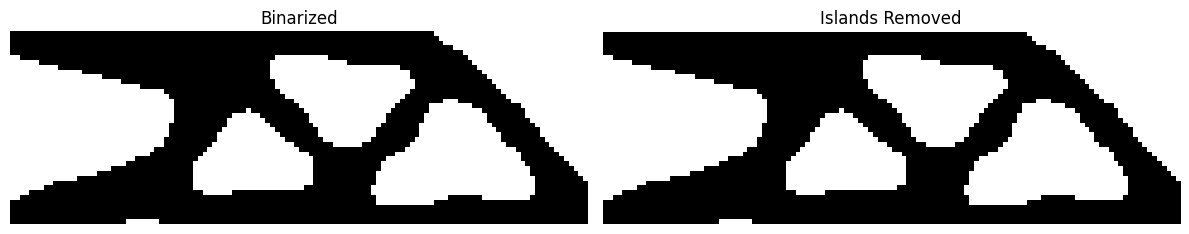

In [8]:
import numpy as np
from scipy.ndimage import label, binary_fill_holes

# ------------------------------------------------------------------ #
#  1. 二值化
# ------------------------------------------------------------------ #
threshold = 0.5
tt_bin = (tt >= threshold).astype(np.uint8)

# ------------------------------------------------------------------ #
#  2. 去除孤岛（保留最大连通域）
# ------------------------------------------------------------------ #
structure = np.ones((3, 3), dtype=int)          # 8-连通
labeled, num_features = label(tt_bin, structure=structure)

if num_features == 0:
    tt_clean = tt_bin.copy()
else:
    # 统计每个连通域的像素数，保留最大的
    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0                      # 背景不参与比较
    largest_label = component_sizes.argmax()
    tt_clean = (labeled == largest_label).astype(np.uint8)

print(f"二值化后体积分数   : {tt_bin.mean():.4f}")
print(f"去孤岛后体积分数   : {tt_clean.mean():.4f}")
print(f"连通域数量         : {num_features}")

# ------------------------------------------------------------------ #
#  3. 可视化对比
# ------------------------------------------------------------------ #
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(1 - tt_bin,  cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Binarized")
axes[0].axis('off')

axes[1].imshow(1 - tt_clean, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Islands Removed")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("tt_clean.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def calc_compliance(xPhys, penal=3):
    """
    计算给定密度矩阵的 compliance。

    Parameters
    ----------
    xPhys : np.ndarray, shape (nely, nelx)
        密度矩阵，值域 [0, 1]。
    penal : float
        惩罚指数，默认 3。

    Returns
    -------
    c : float
        结构柔度（compliance）。
    """
    nely, nelx = xPhys.shape

    # ------------------------------------------------------------------ #
    #  MATERIAL PROPERTIES
    # ------------------------------------------------------------------ #
    E0   = 1000.0
    Emin = 1e-9
    nu   = 0.3

    # ------------------------------------------------------------------ #
    #  ELEMENT STIFFNESS MATRIX
    # ------------------------------------------------------------------ #
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    # ------------------------------------------------------------------ #
    #  DOF MAP
    # ------------------------------------------------------------------ #
    ndof    = 2 * (nelx + 1) * (nely + 1)
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    # ------------------------------------------------------------------ #
    #  LOADS AND SUPPORTS
    #  右上角节点施加向下集中力，左边全固定
    # ------------------------------------------------------------------ #
    F = np.zeros(ndof)
    F[2 * (nelx * (nely + 1) + nely) + 1] = -0.1

    fixeddofs = np.arange(0, 2 * (nely + 1))
    freedofs  = np.setdiff1d(np.arange(ndof), fixeddofs)

    # ------------------------------------------------------------------ #
    #  ASSEMBLE & SOLVE
    # ------------------------------------------------------------------ #
    elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
    sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
    K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
    K  = (K + K.T) / 2

    U = np.zeros(ndof)
    U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

    # ------------------------------------------------------------------ #
    #  COMPLIANCE
    # ------------------------------------------------------------------ #
    Ue = U[edofMat]
    ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
    c  = np.sum((Emin + xPhys**penal * (E0 - Emin)) * ce)

    return c

In [ ]:
#binary
calc_compliance(tt_clean)

0.0019068614290261793

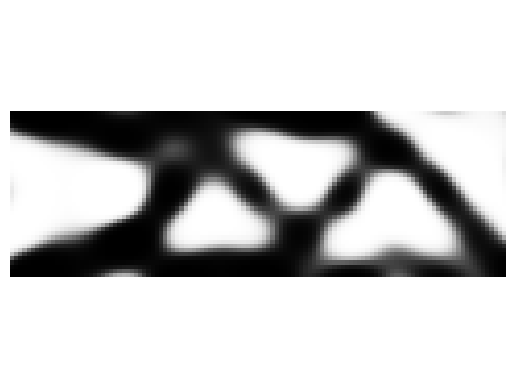

In [12]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(-tt, cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.savefig("./RFM2Dbeam.pdf",dpi=300)